# HARGPT Raw Window Export

Cut ACC to the video-aligned subset once, build a window index, then generate a HARGPT-style prompt from 3 consecutive windows.

In [1]:
from pathlib import Path
import pandas as pd

from video_ltc import ensure_video_timecode_csv

PROJECT_ROOT = Path.cwd().resolve().parent
OUTPUT_DIR = Path.cwd() / "outputs"
VIDEO_DIR = Path.cwd() / "videos"
OUTPUT_DIR.mkdir(exist_ok=True)
VIDEO_DIR.mkdir(exist_ok=True)

PARTICIPANT_ID = "65"
VIDEO_NAME = "GL040221"
RECORD_DATE = pd.Timestamp("2025-07-17").date()
VIDEO_FILE = None
VIDEO_START_TIMECODE = None
VIDEO_FPS = None
FORCE_REGENERATE_VIDEO_METADATA = False

TARGET_FS = 50.0
WINDOW_SECONDS = 4.0
STRIDE_SECONDS = 2.0
WINDOW_SIZE = int(TARGET_FS * WINDOW_SECONDS)
STRIDE_SIZE = int(TARGET_FS * STRIDE_SECONDS)

ACC_FILE = PROJECT_ROOT / "acc_files_cup" / PARTICIPANT_ID / "ACC_0.csv"
VIDEO_FILE, VIDEO_TIMECODE_FILE, VIDEO_METADATA_FILE = ensure_video_timecode_csv(
    video_name=VIDEO_NAME,
    video_file=VIDEO_FILE,
    videos_dir=VIDEO_DIR,
    fallback_timecode=VIDEO_START_TIMECODE,
    fallback_fps=VIDEO_FPS,
    regenerate=FORCE_REGENERATE_VIDEO_METADATA,
)
WINDOW_INDEX_CSV = OUTPUT_DIR / f"hargpt_window_index_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"
ACC_VIDEO_CSV = OUTPUT_DIR / f"hargpt_acc_video_subset_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"

def parse_time_column(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series.astype(str).str.strip(), errors="coerce")

def load_cup_acc_csv(acc_file: Path) -> pd.DataFrame:
    df = pd.read_csv(acc_file)
    rename_map = {"X": "x", "Y": "y", "Z": "z"}
    df = df.rename(columns=rename_map)
    df = df[["time", "x", "y", "z"]].copy()
    df["time"] = parse_time_column(df["time"])
    df = df.dropna(subset=["time", "x", "y", "z"]).sort_values("time")
    df = df.drop_duplicates(subset=["time"]).reset_index(drop=True)
    return df

def resample_acc(df: pd.DataFrame, target_fs: float) -> pd.DataFrame:
    freq_ms = int(round(1000.0 / target_fs))
    rule = f"{freq_ms}ms"
    return (
        df.set_index("time")[["x", "y", "z"]]
        .resample(rule)
        .mean()
        .interpolate(method="time")
        .dropna()
        .reset_index()
    )

def load_video_range(video_timecode_file: Path, record_date):
    vid = pd.read_csv(video_timecode_file)
    vid["tc_hms"] = vid["tc_str"].astype(str).str.slice(0, 8)
    vid["video_datetime"] = pd.to_datetime(
        record_date.strftime("%Y-%m-%d") + " " + vid["tc_hms"],
        errors="coerce"
    )
    vid = vid.dropna(subset=["video_datetime"]).sort_values("video_datetime").reset_index(drop=True)
    return vid["video_datetime"].iloc[0], vid["video_datetime"].iloc[-1]

def split_windows(df: pd.DataFrame, window_size: int, stride_size: int) -> pd.DataFrame:
    rows = []
    if len(df) < window_size:
        return pd.DataFrame(rows)
    for start in range(0, len(df) - window_size + 1, stride_size):
        end = start + window_size
        window_df = df.iloc[start:end].copy().reset_index(drop=True)
        rows.append({
            "window_id": len(rows),
            "start_idx_in_video_subset": int(start),
            "end_idx_in_video_subset": int(end - 1),
            "start_time": window_df.loc[0, "time"],
            "end_time": window_df.loc[len(window_df) - 1, "time"],
        })
    return pd.DataFrame(rows)

raw_acc = load_cup_acc_csv(ACC_FILE)
acc_resampled = resample_acc(raw_acc, TARGET_FS)
video_start, video_end = load_video_range(VIDEO_TIMECODE_FILE, RECORD_DATE)
acc_video = acc_resampled[(acc_resampled["time"] >= video_start) & (acc_resampled["time"] <= video_end)].copy().reset_index(drop=True)
if len(acc_video) < WINDOW_SIZE:
    raise ValueError("Video subset is shorter than one analysis window.")

acc_video.to_csv(ACC_VIDEO_CSV, index=False)
window_index_df = split_windows(acc_video, WINDOW_SIZE, STRIDE_SIZE)
window_index_df.to_csv(WINDOW_INDEX_CSV, index=False)

print(f"Video file: {VIDEO_FILE}")
print(f"Video timecode CSV: {VIDEO_TIMECODE_FILE}")
print(f"Video metadata JSON: {VIDEO_METADATA_FILE}")
print(f"ACC video subset saved to: {ACC_VIDEO_CSV}")
print(f"Window index saved to: {WINDOW_INDEX_CSV}")
print(f"Video range: {video_start} -> {video_end}")
print(f"Video-subset windows: {len(window_index_df)}")
window_index_df.head()


Video file: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\videos\GL040221.lrv
Video timecode CSV: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\videos\video_timecode_1HzGL040221.csv
Video metadata JSON: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\videos\video_metadata_GL040221.json
ACC video subset saved to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\hargpt_acc_video_subset_65_GL040221.csv
Window index saved to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\hargpt_window_index_65_GL040221.csv
Video range: 2025-07-17 13:57:38 -> 2025-07-17 14:09:25
Video-subset windows: 352


,window_id,start_idx_in_video_subset,end_idx_in_video_subset,start_time,end_time
0,0,0,199,2025-07-17 13:57:38,2025-07-17 13:57:41.980
1,1,100,299,2025-07-17 13:57:40,2025-07-17 13:57:43.980
2,2,200,399,2025-07-17 13:57:42,2025-07-17 13:57:45.980
3,3,300,499,2025-07-17 13:57:44,2025-07-17 13:57:47.980
4,4,400,599,2025-07-17 13:57:46,2025-07-17 13:57:49.980


In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

WINDOW_INDEX_IN_VIDEO_SUBSET = 70
PROMPT_WINDOW_COUNT = 24

window_index_df = pd.read_csv(WINDOW_INDEX_CSV)
window_index_df["start_time"] = pd.to_datetime(window_index_df["start_time"])
window_index_df["end_time"] = pd.to_datetime(window_index_df["end_time"])
acc_video = pd.read_csv(ACC_VIDEO_CSV)
acc_video["time"] = pd.to_datetime(acc_video["time"])

if WINDOW_INDEX_IN_VIDEO_SUBSET + PROMPT_WINDOW_COUNT > len(window_index_df):
    raise ValueError(f"Need {PROMPT_WINDOW_COUNT} consecutive windows starting at {WINDOW_INDEX_IN_VIDEO_SUBSET}, but only {len(window_index_df)} windows are available.")

selected_meta = window_index_df.iloc[WINDOW_INDEX_IN_VIDEO_SUBSET: WINDOW_INDEX_IN_VIDEO_SUBSET + PROMPT_WINDOW_COUNT].copy()
SEMANTIC_CLASSES = [
    "still",
    "hand switch",
    "gesture",
    "nodding",
    "raise to lip",
    "drink at lip",
    "return from lip",
    "uncertain",
]

def summarize_axis(series: pd.Series) -> dict:
    values = series.astype(float).to_numpy()
    return {
        "mean": round(float(np.mean(values)), 6),
        "std": round(float(np.std(values, ddof=0)), 6),
    }

window_payloads = []
for row in selected_meta.itertuples(index=False):
    start_idx = int(row.start_idx_in_video_subset)
    end_idx = int(row.end_idx_in_video_subset) + 1
    window_df = acc_video.iloc[start_idx:end_idx].copy().reset_index(drop=True)
    mag = np.sqrt(window_df["x"] ** 2 + window_df["y"] ** 2 + window_df["z"] ** 2)
    window_payloads.append({
        "window_id": int(row.window_id),
        "start_idx_in_video_subset": int(row.start_idx_in_video_subset),
        "end_idx_in_video_subset": int(row.end_idx_in_video_subset),
        "start_time": str(row.start_time),
        "end_time": str(row.end_time),
        "time": [t.isoformat() for t in window_df["time"]],
        "raw_xyz_sequence": {
            "x": [round(float(v), 6) for v in window_df["x"]],
            "y": [round(float(v), 6) for v in window_df["y"]],
            "z": [round(float(v), 6) for v in window_df["z"]],
        },
        "mag_sequence": [round(float(v), 6) for v in mag],
        "axis_stats": {
            "x": summarize_axis(window_df["x"]),
            "y": summarize_axis(window_df["y"]),
            "z": summarize_axis(window_df["z"]),
        },
    })
# maybe learn the classes?
# prove the accuracy of the model?
# more classes for finer grain gestures?
def build_hargpt_prompt(window_payloads):
    return f'''You are an expert of IMU-based human activity analysis.

I will give you raw motion sensor data from a smart cup.
The device contains an accelerometer only.
The device moves with the cup rather than being worn on the body.
The sampling rate is 50 Hz.

Your task is to recognize the most likely activity of each window from the raw sensor sequences.

Candidate classes (use these exact labels):
- still
- hand switch
- gesture
- nodding
- raise to lip
- drink at lip
- return from lip
- uncertain

Please analyze the raw accelerometer data step by step.
For each window:

Analyze the accelerometer signal carefully and reason about the motion patterns before choosing a class.

Your reasoning should emerge from the data itself. Consider aspects such as:
overall motion intensity
variability of acceleration
relationships between x, y, and z axes
raw x/y/z sequences
magnitude sequence
mean/std of each axis
stability or changes in gravity orientation
whether movement is smooth, bursty, or irregular
whether the motion is consistent with hand switch, gesture, nodding, raise to lip, drink at lip, or return from lip
use uncertain when the evidence is ambiguous or mixed
Use temporal continuity across adjacent windows if it helps interpret the motion, but make a separate classification for each window.

Explain briefly how the observed sensor patterns support the chosen class.
Use temporal continuity across adjacent windows when helpful, but output one label for each window separately.
Focus on overall motion intensity, changes across x/y/z axes, whether the movement is smooth or bursty, and whether there is a sustained directional change consistent with drinking.

Return exactly one JSON array with one object per window:
[{{"window_id":0,"predicted_class":"<class>","reason":"<brief explanation>"}}]
Return in JSON file format.
Do not use code script to extract statistical values and still proecess the data directly'''
# Raw data windows:
# {json.dumps(window_payloads, ensure_ascii=False)}


batch_name = f"hargpt_windows_{WINDOW_INDEX_IN_VIDEO_SUBSET}_to_{WINDOW_INDEX_IN_VIDEO_SUBSET + PROMPT_WINDOW_COUNT - 1}_{PARTICIPANT_ID}_{VIDEO_NAME}"
batch_dir = OUTPUT_DIR / batch_name
batch_dir.mkdir(exist_ok=True)
batch_json = batch_dir / f"{batch_name}.json"
prompt_txt = batch_dir / f"{batch_name}_prompt.txt"

batch_json.write_text(json.dumps(window_payloads, indent=2, ensure_ascii=False), encoding="utf-8")
prompt_txt.write_text(build_hargpt_prompt(window_payloads), encoding="utf-8")

print(f"Batch JSON saved to: {batch_json}")
print(f"Prompt text saved to: {prompt_txt}")
selected_meta


Batch JSON saved to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\hargpt_windows_70_to_93_65_GL040221\hargpt_windows_70_to_93_65_GL040221.json
Prompt text saved to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\hargpt_windows_70_to_93_65_GL040221\hargpt_windows_70_to_93_65_GL040221_prompt.txt


,window_id,start_idx_in_video_subset,end_idx_in_video_subset,start_time,end_time
70,70,7000,7199,2025-07-17 13:59:58,2025-07-17 14:00:01.980
71,71,7100,7299,2025-07-17 14:00:00,2025-07-17 14:00:03.980
72,72,7200,7399,2025-07-17 14:00:02,2025-07-17 14:00:05.980
73,73,7300,7499,2025-07-17 14:00:04,2025-07-17 14:00:07.980
74,74,7400,7599,2025-07-17 14:00:06,2025-07-17 14:00:09.980
75,75,7500,7699,2025-07-17 14:00:08,2025-07-17 14:00:11.980
76,76,7600,7799,2025-07-17 14:00:10,2025-07-17 14:00:13.980
77,77,7700,7899,2025-07-17 14:00:12,2025-07-17 14:00:15.980
78,78,7800,7999,2025-07-17 14:00:14,2025-07-17 14:00:17.980
79,79,7900,8099,2025-07-17 14:00:16,2025-07-17 14:00:19.980


In [3]:
import json
import pandas as pd


chatgpt_results = [
{"window_id":70,"predicted_class":"still","reason":"low variance, gravity stable, no sustained tilt or bursts"},
{"window_id":71,"predicted_class":"still","reason":"similar to previous, small fluctuations only"},
{"window_id":72,"predicted_class":"still","reason":"continuation of low-motion regime, stable orientation"},
{"window_id":73,"predicted_class":"gesture","reason":"increase in variance, small bursts without sustained tilt"},
{"window_id":74,"predicted_class":"gesture","reason":"irregular multi-axis fluctuations, no clear drinking pattern"},
{"window_id":75,"predicted_class":"gesture","reason":"moderate motion, no stable tilt plateau"},
{"window_id":76,"predicted_class":"raise to lip","reason":"increasing variance and gradual orientation shift, z deviates from -1"},
{"window_id":77,"predicted_class":"raise to lip","reason":"continued directional change with growing tilt magnitude"},
{"window_id":78,"predicted_class":"raise to lip","reason":"stronger tilt and multi-axis coordination"},
{"window_id":79,"predicted_class":"raise to lip","reason":"very high variance, large orientation change, no plateau yet"},
{"window_id":80,"predicted_class":"drink at lip","reason":"reduced variance after lift, orientation stabilized at tilted state"},
{"window_id":81,"predicted_class":"drink at lip","reason":"sustained tilt with relatively stable magnitude"},
{"window_id":82,"predicted_class":"return from lip","reason":"tilt reverses toward gravity, variance increases"},
{"window_id":83,"predicted_class":"return from lip","reason":"strong multi-axis change, orientation recovering toward baseline"},
{"window_id":84,"predicted_class":"gesture","reason":"post-return irregular motion without sustained tilt"},
{"window_id":85,"predicted_class":"gesture","reason":"moderate fluctuations, no structured drinking pattern"},
{"window_id":86,"predicted_class":"gesture","reason":"continued handling motion, irregular but not directional"},
{"window_id":87,"predicted_class":"still","reason":"variance drops, gravity alignment stable"},
{"window_id":88,"predicted_class":"gesture","reason":"y-axis variability increases, small lateral handling"},
{"window_id":89,"predicted_class":"gesture","reason":"irregular motion across axes, no tilt structure"},
{"window_id":90,"predicted_class":"gesture","reason":"moderate bursts, inconsistent directionality"},
{"window_id":91,"predicted_class":"gesture","reason":"continued handling motion, no plateau"},
{"window_id":92,"predicted_class":"gesture","reason":"multi-axis variation, non-drinking pattern"},
{"window_id":93,"predicted_class":"gesture","reason":"higher x/y variance but z stable, typical hand movement"}
]

window_ids = [item["window_id"] for item in chatgpt_results]
result_name = f"{batch_name}_predictions_local_chatgpt.json"
result_path = batch_dir / result_name
result_path.write_text(json.dumps(chatgpt_results, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Saved ChatGPT results to: {result_path}")
pd.DataFrame(chatgpt_results)


Saved ChatGPT results to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\hargpt_windows_70_to_93_65_GL040221\hargpt_windows_70_to_93_65_GL040221_predictions_local_chatgpt.json


,window_id,predicted_class,reason
0,70,still,"low variance, gravity stable, no sustained til..."
1,71,still,"similar to previous, small fluctuations only"
2,72,still,"continuation of low-motion regime, stable orie..."
3,73,gesture,"increase in variance, small bursts without sus..."
4,74,gesture,"irregular multi-axis fluctuations, no clear dr..."
5,75,gesture,"moderate motion, no stable tilt plateau"
6,76,raise to lip,increasing variance and gradual orientation sh...
7,77,raise to lip,continued directional change with growing tilt...
8,78,raise to lip,stronger tilt and multi-axis coordination
9,79,raise to lip,"very high variance, large orientation change, ..."


In [4]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# Set the plot style and background color to white
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["savefig.edgecolor"] = "white"
plt.rcParams["savefig.transparent"] = False

ValueError: cannot convert float NaN to integer

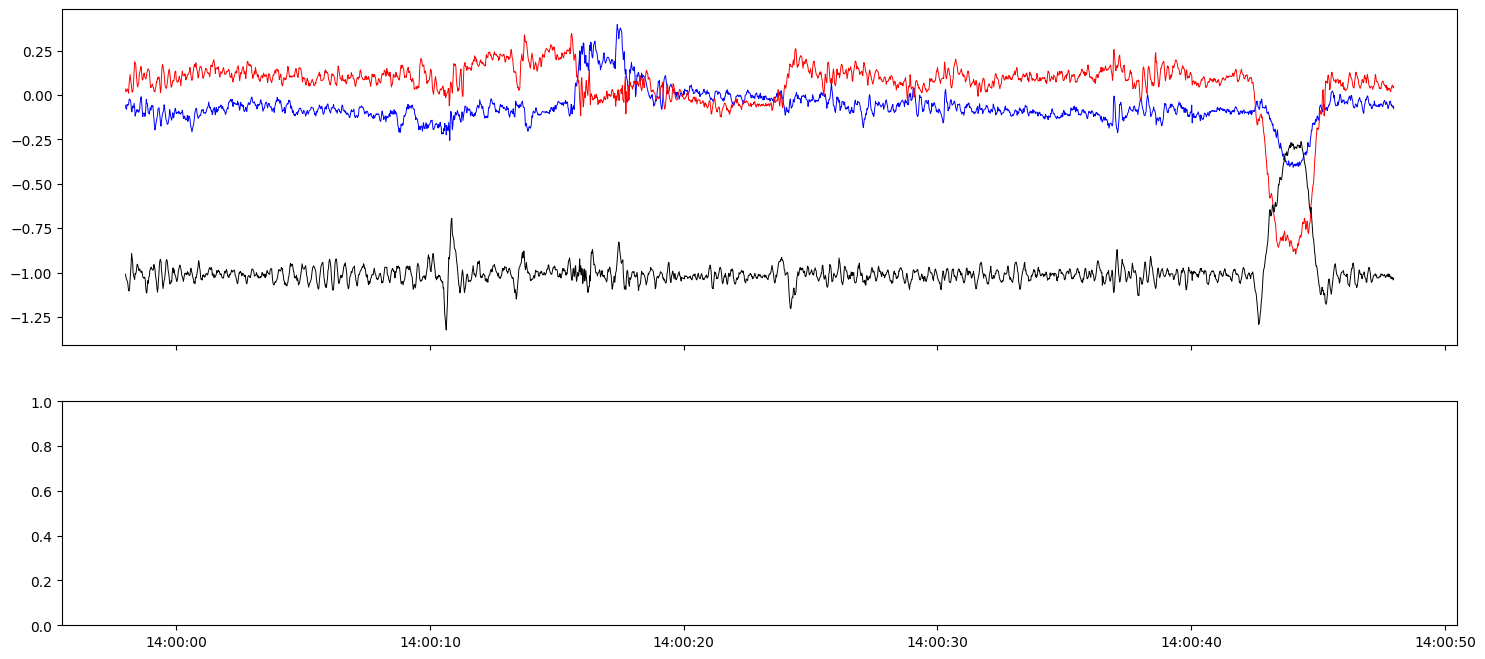

In [6]:
WINDOW_RANGE = f"{min(window_ids)}_{max(window_ids)}"
RESULT_PATH = result_path
WEAK_LABEL_FILE = OUTPUT_DIR / f"rule_generated_labels_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"
COMPARE_PNG = batch_dir / f"{batch_name}_predictions_chatgpt_vs_weak_labels.png"

label_to_state = {"Still": 0, "Activity": 1, "Drinking": 2}
state_to_name = {0: "Still", 1: "Activity", 2: "Drinking"}
state_colors = {0: "white", 1: "orange", 2: "green"}

fine_class_to_state = {
    "still": 0,
    "hand switch": 1,
    "gesture": 1,
    "nodding": 1,
    "raise to lip": 2,
    "drink at lip": 2,
    "return from lip": 2,
    "uncertain": 1,
}


def normalize_label(value):
    if pd.isna(value):
        return pd.NA
    return str(value).strip().lower()


def map_prediction_to_state(value):
    normalized = normalize_label(value)
    if pd.isna(normalized):
        return pd.NA
    if normalized == "still":
        return 0
    if normalized in fine_class_to_state:
        return fine_class_to_state[normalized]
    title_label = str(value).strip().title()
    if title_label in label_to_state:
        return label_to_state[title_label]
    return pd.NA


window_index_df = pd.read_csv(WINDOW_INDEX_CSV)
window_index_df["start_time"] = pd.to_datetime(window_index_df["start_time"])
window_index_df["end_time"] = pd.to_datetime(window_index_df["end_time"])
acc_video = pd.read_csv(ACC_VIDEO_CSV)
acc_video["time"] = pd.to_datetime(acc_video["time"])
weak_df = pd.read_csv(WEAK_LABEL_FILE)
weak_df["time"] = pd.to_datetime(weak_df["time"])
predictions = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
pred_df = pd.DataFrame(predictions)

required_cols = {"window_id", "predicted_class"}
missing_cols = required_cols - set(pred_df.columns)
if missing_cols:
    raise ValueError(f"Prediction JSON missing required fields: {sorted(missing_cols)}")

pred_df["predicted_state"] = pred_df["predicted_class"].map(map_prediction_to_state)
pred_df = pred_df.merge(window_index_df[["window_id", "start_time", "end_time"]], on="window_id", how="left")
pred_df = pred_df.sort_values("window_id").reset_index(drop=True)

invalid_rows = pred_df[
    pred_df[["predicted_state", "start_time", "end_time"]].isna().any(axis=1)
].copy()
if not invalid_rows.empty:
    print("Invalid prediction rows detected:")
    display(invalid_rows[["window_id", "predicted_class", "predicted_state", "start_time", "end_time"]])
    pred_df = pred_df.drop(index=invalid_rows.index).reset_index(drop=True)

if pred_df.empty:
    raise ValueError("No valid prediction windows available for plotting after validation.")

pred_df["predicted_state"] = pred_df["predicted_state"].astype(int)

plot_start = pred_df["start_time"].min()
plot_end = pred_df["end_time"].max()
acc_plot = acc_video[(acc_video["time"] >= plot_start) & (acc_video["time"] <= plot_end)].copy().reset_index(drop=True)
weak_plot = weak_df[(weak_df["time"] >= plot_start) & (weak_df["time"] <= plot_end)].copy().reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
ax0, ax1 = axes
fig.patch.set_facecolor("white")
ax0.set_facecolor("white")
ax1.set_facecolor("white")


ax0.plot(acc_plot["time"], acc_plot["x"], label="x", color="blue", linewidth=0.7)
ax0.plot(acc_plot["time"], acc_plot["y"], label="y", color="red", linewidth=0.7)
ax0.plot(acc_plot["time"], acc_plot["z"], label="z", color="black", linewidth=0.7)
for row in pred_df.itertuples(index=False):
    ax0.axvspan(row.start_time, row.end_time, color=state_colors[row.predicted_state], alpha=0.18)
ax0.set_title("ACC with ChatGPT predicted windows")
ax0.set_ylabel("Acceleration")
ax0.legend(loc="upper right")

for row in pred_df.itertuples(index=False):
    ax1.axvspan(row.start_time, row.end_time, ymin=0.52, ymax=0.98, color=state_colors[row.predicted_state], alpha=0.45)
    # ax1.text(row.start_time + (row.end_time - row.start_time) / 2, 0.75, f"P{row.window_id}:{row.predicted_class}", ha="center", va="center", fontsize=8)

weak_runs = []
if not weak_plot.empty:
    weak_plot = weak_plot.sort_values("time").reset_index(drop=True)
    start_idx = 0
    for i in range(1, len(weak_plot) + 1):
        if i == len(weak_plot) or weak_plot.loc[i, "weak_label"] != weak_plot.loc[i - 1, "weak_label"]:
            weak_runs.append((weak_plot.loc[start_idx, "time"], weak_plot.loc[i - 1, "time"], weak_plot.loc[i - 1, "weak_label"]))
            start_idx = i

for start_time, end_time, weak_label in weak_runs:
    weak_state = label_to_state.get(str(weak_label), 1)
    ax1.axvspan(start_time, end_time, ymin=0.02, ymax=0.48, color=state_colors[int(weak_state)], alpha=0.45)
    # ax1.text(start_time + (end_time - start_time) / 2, 0.25, f"W:{weak_label}", ha="center", va="center", fontsize=8)

ax1.set_ylim(0, 1)
ax1.set_yticks([0.25, 0.75])
ax1.set_yticklabels(["Weak label", "ChatGPT"])
ax1.set_title("Weak labels vs ChatGPT predictions")
ax1.set_xlabel("Time")

legend_handles = [Patch(facecolor=state_colors[s], edgecolor="gray", label=state_to_name[s]) for s in [0, 1, 2]]
ax1.legend(handles=legend_handles, loc="upper right")
fig.tight_layout()
fig.savefig(COMPARE_PNG, dpi=200, bbox_inches="tight", facecolor="white", edgecolor="white", transparent=False)
print(f"Saved comparison plot to: {COMPARE_PNG}")
pred_df[["window_id", "predicted_class", "predicted_state", "start_time", "end_time"]]

